# Linear Regression Practical

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)

X = boston.data
y = boston.target

# type(load_boston)
# print(X.head())
# print(y.head())

In [41]:
dataset = pd.DataFrame(boston.data)
dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


## About Feactures

In [42]:
# Independent and Dependent features

X = dataset
y = boston.target

In [43]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [44]:
# Train, Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3 , random_state=42)

In [45]:
# Standerdize the dataset

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [46]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train,y_train)

# cross validation

from sklearn.model_selection import cross_val_score

In [48]:
mse = cross_val_score(regression , X_train, y_train, scoring='neg_mean_squared_error',cv=5)

In [49]:
np.mean(mse)

np.float64(-25.977777430926295)

In [50]:
## Prediction

reg_pred = regression.predict(X_test)

In [51]:
reg_pred

array([28.64896005, 36.49501384, 15.4111932 , 25.40321303, 18.85527988,
       23.14668944, 17.3921241 , 14.07859899, 23.03692679, 20.59943345,
       24.82286159, 18.53057049, -6.86543527, 21.80172334, 19.22571177,
       26.19191985, 20.27733882,  5.61596432, 40.44887974, 17.57695918,
       27.44319095, 30.1715964 , 10.94055823, 24.02083139, 18.07693812,
       15.934748  , 23.12614028, 14.56052142, 22.33482544, 19.3257627 ,
       22.16564973, 25.19476081, 25.31372473, 18.51345025, 16.6223286 ,
       17.50268505, 30.94992991, 20.19201752, 23.90440431, 24.86975466,
       13.93767876, 31.82504715, 42.56978796, 17.62323805, 27.01963242,
       17.19006621, 13.80594006, 26.10356557, 20.31516118, 30.08649576,
       21.3124053 , 34.15739602, 15.60444981, 26.11247588, 39.31613646,
       22.99282065, 18.95764781, 33.05555669, 24.85114223, 12.91729352,
       22.68101452, 30.80336295, 31.63522027, 16.29833689, 21.07379993,
       16.57699669, 20.36362023, 26.15615896, 31.06833034, 11.98

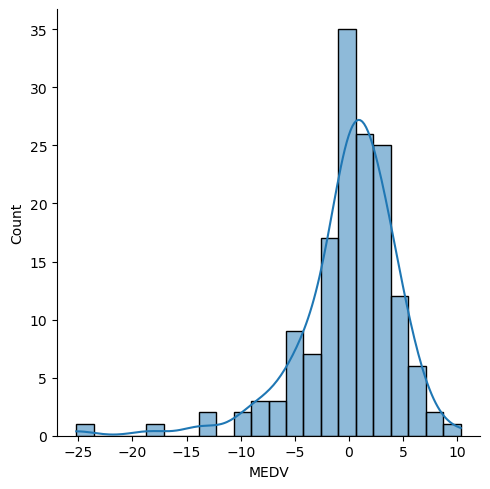

In [14]:
sns.displot(reg_pred-y_test , kde=True)

In [52]:
from sklearn.metrics import r2_score

score = r2_score(reg_pred , y_test)

score

0.6693702691495593

# Multiple Linear Regression

In [16]:
dataset = pd.read_csv('../datasets/50_Startups.csv')

In [17]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [18]:
# Here profit is dependent feature and is dependent on R&D Spend, Administration, Marketing Spend, State

X = dataset.iloc[:,:-1]
y = dataset.iloc[:,4]

In [19]:
X

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


In [20]:
states = pd.get_dummies(X['State'] , drop_first=True)

In [21]:
X = X.drop('State',axis=1)

X = pd.concat([X,states],axis = 1)

In [22]:
X

,R&D Spend,Administration,Marketing Spend,Florida,New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train

,R&D Spend,Administration,Marketing Spend,Florida,New York
12,93863.75,127320.38,249839.44,True,False
4,142107.34,91391.77,366168.42,True,False
37,44069.95,51283.14,197029.42,False,False
8,120542.52,148718.95,311613.29,False,True
3,144372.41,118671.85,383199.62,False,True
6,134615.46,147198.87,127716.82,False,False
41,27892.92,84710.77,164470.71,True,False
46,1315.46,115816.21,297114.46,True,False
47,0.00,135426.92,0.00,False,False
15,114523.61,122616.84,261776.23,False,True


#### Equation :- hθ​(x)​=θ0​+θ1​(R&D Spend)+θ2​(Administration)+θ3​(Marketing Spend)+θ4​(Florida)+θ5​(New York)​

In [25]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train,y_train)

y_pred = regression.predict(X_test)

In [26]:
y_pred

array([126362.87908255,  84608.45383634,  99677.49425147,  46357.46068582,
       128750.48288504,  50912.4174188 , 109741.35032702, 100643.24281647,
        97599.27574594, 113097.42524432])

In [27]:
from sklearn.metrics import r2_score

score = r2_score(y_test,y_pred)

score

0.8987266414328636

# Ridge Regression

In [53]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [54]:
ridge_regressor = Ridge()

In [55]:
ridge_regressor

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [56]:
parameters = {'alpha':[1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,90]}

ridgeCV = GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv=5)

ridgeCV.fit(X_train,y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [1, 2, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [57]:
print(ridgeCV.best_params_)

print(ridgeCV.best_score_)

{'alpha': 10}
-25.807228822291457


In [58]:
ridge_pred = ridgeCV.predict(X_test)

<Axes: xlabel='MEDV', ylabel='Count'>

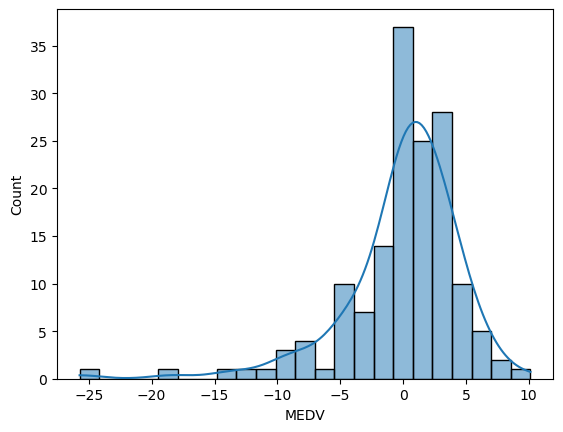

In [63]:
import seaborn as sns
sns.histplot(ridge_pred-y_test,kde=True)

In [64]:
from sklearn.metrics import r2_score

score = r2_score(y_test,ridge_pred)

score

0.7072830902371285

# Lasso Regression

In [65]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [66]:
lasso_regressor = Lasso()

In [67]:
parameters = {'alpha':[1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,90]}

lassoCV = GridSearchCV(lasso_regressor,parameters,scoring='neg_mean_squared_error',cv=5)

lassoCV.fit(X_train,y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [1, 2, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [69]:
print(lassoCV.best_params_)

print(lassoCV.best_score_)

{'alpha': 1}
-31.153603752119004


<Axes: xlabel='MEDV', ylabel='Count'>

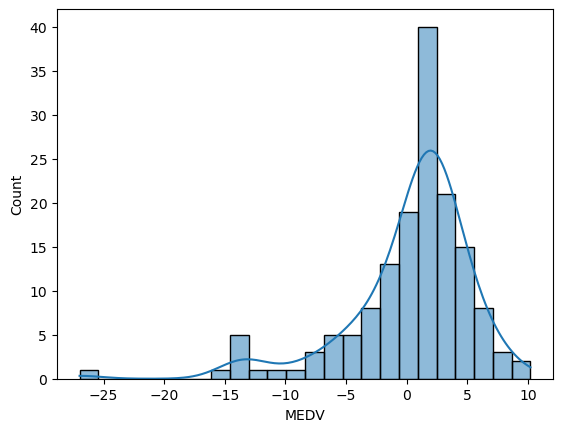

In [72]:
lasso_pred = lassoCV.predict(X_test)

import seaborn as sns
sns.histplot(lasso_pred-y_test,kde=True)

In [73]:
from sklearn.metrics import r2_score

score = r2_score(y_test,lasso_pred)

score

0.6439219427114921